# Conditional Autoregressive Spectrogram Transformer

Extra / future work: this notebook is a report-first companion for the
historical continuous Transformer generator. It produces normalized
128 x 128 log-mel spectrograms conditioned on bird species; it is not part of
the current CRNN augmentation focus.


## Goal

1. Inspect the shared cached representation and causal patch order.
2. Show the recorded Transformer training and classifier diagnostics.
3. Keep retraining, generation, and classifier scoring available as explicit,
   opt-in experiments.
4. Separate classifier agreement from perceptual realism and audio quality.

Report-mode cells run without requiring the ignored historical checkpoint.


## 1. Setup

Reusable model, data, training, and generation logic lives under `src/bird_song/transformer/`. The notebook calls those modules instead of duplicating the implementation.

In [1]:
from pathlib import Path
import json
import os
import subprocess
import sys

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import numpy as np
import pandas as pd
import torch
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent
SOURCE_ROOT = PROJECT_ROOT / "src"
if str(SOURCE_ROOT) not in sys.path:
    sys.path.insert(0, str(SOURCE_ROOT))

from bird_song.runtime import seed_everything
from bird_song.transformer.data import CachedSpectrogramDataset, make_cached_loader
from bird_song.transformer.model import (
    ConditionalSpectrogramTransformer,
    TransformerGeneratorConfig,
    count_trainable_parameters,
)

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    torch.set_float32_matmul_precision("high")
    torch.backends.cudnn.benchmark = True
else:
    DEVICE = torch.device("cpu")

print("Project root:", PROJECT_ROOT)
print("PyTorch:", torch.__version__)
print("Device:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))


Project root: C:\Users\Harvey\Documents\Coding\bird_song_gen
PyTorch: 2.11.0+cu128
Device: cuda
GPU: NVIDIA GeForce RTX 4070 SUPER


## 2. Configuration

This notebook defaults to the tracked report package. The local run directory
is used only when an opt-in experiment is requested; no checkpoint is needed
to inspect the recorded evidence.


In [ ]:
CACHE_ROOT = PROJECT_ROOT / "artifacts" / "spectrograms"
CACHE_MANIFEST = CACHE_ROOT / "spectrogram_manifest.csv"
SPECTROGRAM_CONFIG = PROJECT_ROOT / "configs" / "spectrogram.json"
MODEL_CONFIG = PROJECT_ROOT / "configs" / "transformer.json"
RUN_DIR = PROJECT_ROOT / "runs" / "transformer_generator"
CHECKPOINT_PATH = RUN_DIR / "best.pt"
GENERATED_DIR = PROJECT_ROOT / "outputs" / "autoregressive_transformer"
CLASSIFIER_CHECKPOINT = PROJECT_ROOT / "artifacts" / "models" / "classifier" / "selected_crnn" / "best.pt"
REPORT_DIR = PROJECT_ROOT / "reports" / "generator_baselines" / "transformer"
RECORDED_HISTORY_PATH = REPORT_DIR / "history.csv"
RECORDED_CRNN_SCORE = REPORT_DIR / "classifier_eval_crnn_t10.summary.json"

SEED = 42
BATCH_SIZE = 32
NOTEBOOK_WORKERS = 0
TRAINING_WORKERS = 4
EPOCHS = 60
PATIENCE = 10
LEARNING_RATE = 2e-4
WEIGHT_DECAY = 1e-4
TEMPERATURE = 0.8
SAMPLES_PER_SPECIES = 8

RUN_TRAINING = False
RUN_GENERATION = False
RUN_CLASSIFIER_EVALUATION = False
OVERWRITE_OUTPUTS = False

seed_everything(SEED)
model_config = TransformerGeneratorConfig.from_json(MODEL_CONFIG)
recorded_config = json.loads((REPORT_DIR / "config.json").read_text(encoding="utf-8"))
classes = tuple(recorded_config["classes"])


## 3. Cached Log-mel Images

The transformer uses the same fixed, normalized Stage 2 representation as the VAE and diffusion model. The test split is not used for training or early stopping.

In [3]:
if CACHE_MANIFEST.is_file():
    cache_rows = pd.read_csv(CACHE_MANIFEST)
    classes = tuple(sorted(cache_rows["name"].unique()))
    class_to_index = {name: index for index, name in enumerate(classes)}
    train_dataset = CachedSpectrogramDataset(
        CACHE_MANIFEST, CACHE_ROOT, "train", classes, model_config.image_size
    )
    validation_dataset = CachedSpectrogramDataset(
        CACHE_MANIFEST, CACHE_ROOT, "validation", classes, model_config.image_size
    )
    train_loader = make_cached_loader(
        train_dataset, BATCH_SIZE, NOTEBOOK_WORKERS, training=True, seed=SEED
    )
    validation_loader = make_cached_loader(
        validation_dataset, BATCH_SIZE, NOTEBOOK_WORKERS
    )
    split_counts = cache_rows.groupby(["split", "name"]).size().rename("images").reset_index()
    display(split_counts)
    print("Classes:", classes)
    print("Train images:", len(train_dataset))
    print("Validation images:", len(validation_dataset))
else:
    cache_rows = pd.DataFrame()
    train_dataset = validation_dataset = train_loader = validation_loader = None
    print("Cached spectrograms are unavailable; report-only cells remain runnable.")


,split,name,images
0,test,American Robin,145
1,test,Northern Cardinal,162
2,test,Song Sparrow,182
3,train,American Robin,709
4,train,Northern Cardinal,740
5,train,Song Sparrow,890
6,validation,American Robin,163
7,validation,Northern Cardinal,172
8,validation,Song Sparrow,184


Classes: ('American Robin', 'Northern Cardinal', 'Song Sparrow')
Train images: 2339
Validation images: 519


### Real Training Images

These are the normalized image targets the autoregressive likelihood learns to model.

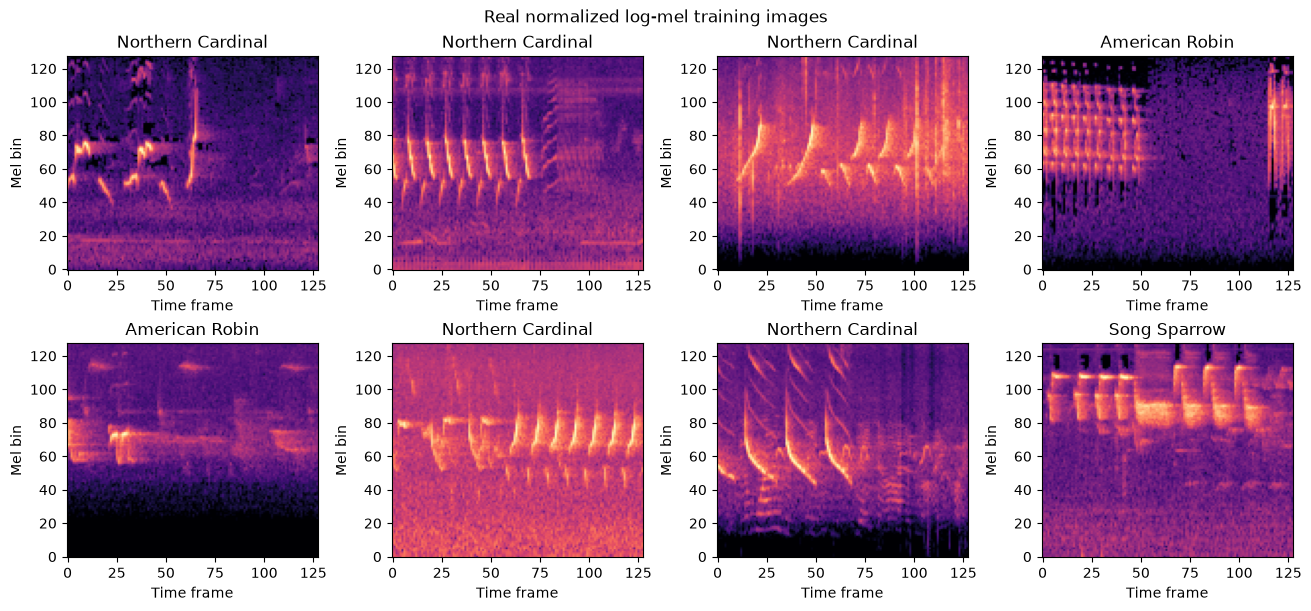

Batch shape: (32, 1, 128, 128)
Value range: -1.0 to 1.0


In [4]:
if train_loader is not None:
    real_images, real_labels, real_paths = next(iter(train_loader))
    fig, axes = plt.subplots(2, 4, figsize=(13, 6), constrained_layout=True)
    for axis, image, label in zip(axes.flat, real_images[:8], real_labels[:8]):
        axis.imshow(image.squeeze(0), origin="lower", aspect="auto", cmap="magma", vmin=-1, vmax=1)
        axis.set_title(classes[int(label)])
        axis.set_xlabel("Time frame")
        axis.set_ylabel("Mel bin")
    fig.suptitle("Real normalized log-mel training images")
    plt.show()
    print("Batch shape:", tuple(real_images.shape))
    print("Value range:", float(real_images.min()), "to", float(real_images.max()))
else:
    real_images = real_labels = real_paths = None
    print("Load the cached spectrograms to preview real training images.")


## 4. Autoregressive Patch Order

A 16 x 16 patch size creates an 8 x 8 grid. Generation proceeds **time block first**, then from lower to higher frequency blocks within that time region. At each step the causal mask prevents access to future patches.

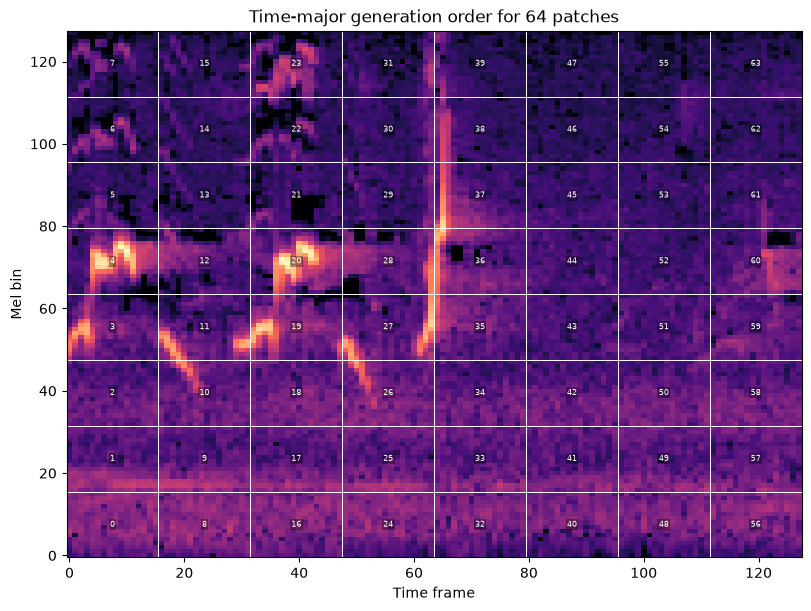

In [5]:
if real_images is not None:
    patch_size = model_config.patch_size
    grid_size = model_config.grid_size
    example_image = real_images[0, 0].numpy()
    fig, axis = plt.subplots(figsize=(8, 6), constrained_layout=True)
    axis.imshow(example_image, origin="lower", aspect="auto", cmap="magma", vmin=-1, vmax=1)
    for time_block in range(grid_size):
        for frequency_block in range(grid_size):
            step = time_block * grid_size + frequency_block
            x = time_block * patch_size - 0.5
            y = frequency_block * patch_size - 0.5
            axis.add_patch(Rectangle((x, y), patch_size, patch_size, fill=False, edgecolor="white", linewidth=0.6))
            axis.text(
                x + patch_size / 2, y + patch_size / 2, str(step),
                color="white", fontsize=6, ha="center", va="center",
                bbox={"facecolor": "black", "alpha": 0.35, "pad": 1, "edgecolor": "none"},
            )
    axis.set(title="Time-major generation order for 64 patches", xlabel="Time frame", ylabel="Mel bin")
    plt.show()
else:
    print("Patch-order visualization requires the cached spectrograms.")


## 5. Generator Architecture

```text
species label -> learned species embedding -------------------+
                                                             |
previous patches -> linear patch embeddings -> positions -> causal transformer
                                                             |
                                      Gaussian mean + scale for next patch
                                                             |
                                             sample and append patch
```

Training uses teacher forcing: the model sees real previous patches and predicts every next-patch distribution in parallel. Generation is sequential and samples from the learned distributions.

In [6]:
generator_model = ConditionalSpectrogramTransformer(model_config).to(DEVICE)
print(f"Trainable parameters: {count_trainable_parameters(generator_model):,}")
if real_images is not None:
    with torch.inference_mode():
        patch_mean, patch_log_scale = generator_model(
            real_images[:2].to(DEVICE), real_labels[:2].to(DEVICE)
        )
    print("Predicted patch means:", tuple(patch_mean.shape))
    print("Predicted patch log-scales:", tuple(patch_log_scale.shape))
    print("Expected: batch x 64 patches x 256 values")
else:
    print("Forward-shape check deferred until cached images are available.")
del generator_model


C:\Users\Harvey\Documents\Coding\bird_song_gen\src\bird_song\transformer\model.py:90: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=config.num_layers)


Trainable parameters: 4,953,856


Predicted patch means: (2, 64, 256)
Predicted patch log-scales: (2, 64, 256)
Expected: batch x 64 patches x 256 values


## 6. Project Command Helper

Training and generation run as standalone scripts. This is safer with Windows DataLoader workers and ensures the notebook uses exactly the same implementation as command-line experiments.

In [7]:
def run_project_script(script_name, arguments):
    environment = os.environ.copy()
    existing_pythonpath = environment.get('PYTHONPATH')
    environment['PYTHONPATH'] = str(SOURCE_ROOT) + (
        os.pathsep + existing_pythonpath if existing_pythonpath else ''
    )
    command = [sys.executable, str(PROJECT_ROOT / 'scripts' / script_name), *map(str, arguments)]
    print('Running:', ' '.join(command))
    return subprocess.run(command, cwd=PROJECT_ROOT, env=environment, check=True)

## 7. Optional Training

Set `RUN_TRAINING = True` in the configuration cell to train. The best checkpoint is selected by validation negative log likelihood. Existing run files are protected unless `OVERWRITE_OUTPUTS = True`.

In [8]:
if RUN_TRAINING:
    training_arguments = [
        "--cache-manifest", CACHE_MANIFEST,
        "--cache-root", CACHE_ROOT,
        "--spectrogram-config", SPECTROGRAM_CONFIG,
        "--model-config", MODEL_CONFIG,
        "--output-dir", RUN_DIR,
        "--epochs", EPOCHS,
        "--patience", PATIENCE,
        "--batch-size", BATCH_SIZE,
        "--workers", TRAINING_WORKERS,
        "--learning-rate", LEARNING_RATE,
        "--weight-decay", WEIGHT_DECAY,
        "--seed", SEED,
        "--device", DEVICE,
    ]
    if OVERWRITE_OUTPUTS:
        training_arguments.append("--overwrite")
    run_project_script("06_train_transformer.py", training_arguments)
else:
    print("Training disabled. Set RUN_TRAINING = True for a new future-work run.")


Training disabled. Set RUN_TRAINING = True for a new future-work run.


### Training Curves

Both losses are Gaussian patch negative log likelihood; lower is better. A widening train-validation gap suggests overfitting.

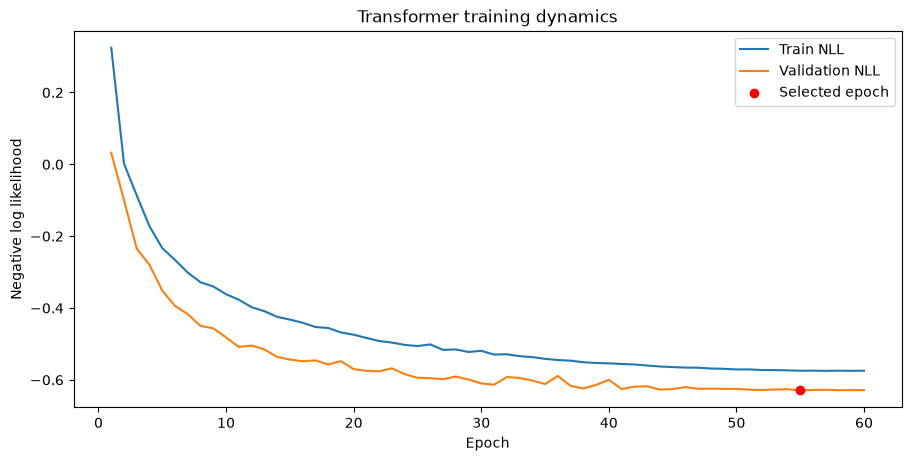

,epoch,train_nll,validation_nll,lr,seconds
55,56,-0.574350,-0.628096,3.407417e-06,0.951755
56,57,-0.574966,-0.627547,2.185240e-06,0.928582
57,58,-0.574420,-0.628622,1.231166e-06,0.935471
58,59,-0.574847,-0.628560,5.478105e-07,0.934498
59,60,-0.574484,-0.628472,1.370465e-07,0.952286


History source: C:\Users\Harvey\Documents\Coding\bird_song_gen\reports\generator_baselines\transformer\history.csv


In [9]:
history_path = RUN_DIR / "history.csv" if RUN_TRAINING and (RUN_DIR / "history.csv").is_file() else RECORDED_HISTORY_PATH
if history_path.is_file():
    history = pd.read_csv(history_path)
    best_row = history.loc[history["validation_nll"].idxmin()]
    fig, axis = plt.subplots(figsize=(9, 4.5), constrained_layout=True)
    axis.plot(history["epoch"], history["train_nll"], label="Train NLL")
    axis.plot(history["epoch"], history["validation_nll"], label="Validation NLL")
    axis.scatter(best_row["epoch"], best_row["validation_nll"], color="red", zorder=3, label="Selected epoch")
    axis.set(xlabel="Epoch", ylabel="Negative log likelihood", title="Transformer training dynamics")
    axis.legend()
    plt.show()
    display(history.tail())
    print("History source:", history_path)
else:
    print("No Transformer history found at:", history_path)


### Recorded classifier diagnostics

The retained selected-CRNN score is forced-choice target-label agreement, not
perceptual realism. It is reported as a conditioning diagnostic and should be
interpreted alongside the spectrograms and listening caveats below.


In [ ]:
if not RECORDED_CRNN_SCORE.is_file():
    raise FileNotFoundError(f"Recorded CRNN score is missing: {RECORDED_CRNN_SCORE}")

payload = json.loads(RECORDED_CRNN_SCORE.read_text(encoding="utf-8"))
diagnostic_table = pd.DataFrame([{
    "classifier": "Selected CRNN",
    "samples": payload["num_samples"],
    "target_label_accuracy": payload["target_label_accuracy"],
    "mean_confidence": payload["mean_confidence"],
    "Robin": payload["per_target_accuracy"]["American Robin"],
    "Cardinal": payload["per_target_accuracy"]["Northern Cardinal"],
    "Sparrow": payload["per_target_accuracy"]["Song Sparrow"],
}])
display(diagnostic_table.style.format({
    "target_label_accuracy": "{:.2%}",
    "mean_confidence": "{:.2%}",
    "Robin": "{:.2%}",
    "Cardinal": "{:.2%}",
    "Sparrow": "{:.2%}",
}))

for figure_name in ("temperature_1.0.png", "real_test_samples.png"):
    figure_path = REPORT_DIR / "figures" / figure_name
    if figure_path.is_file():
        display(Image(filename=str(figure_path)))


## 8. Optional Conditional Generation

Set `RUN_GENERATION = True` after training. Temperature controls sampling variability: zero uses patch means, while larger values increase diversity and may also introduce artifacts.

In [11]:
if RUN_GENERATION:
    if not CHECKPOINT_PATH.is_file():
        raise FileNotFoundError(f"Local Transformer checkpoint is required for generation: {CHECKPOINT_PATH}")
    generation_arguments = [
        "--checkpoint", CHECKPOINT_PATH,
        "--output-dir", GENERATED_DIR,
        "--samples-per-species", SAMPLES_PER_SPECIES,
        "--temperature", TEMPERATURE,
        "--seed", SEED,
        "--device", DEVICE,
    ]
    if OVERWRITE_OUTPUTS:
        generation_arguments.append("--overwrite")
    run_project_script("06_generate_transformer.py", generation_arguments)
else:
    print("Generation disabled. Set RUN_GENERATION = True for a new future-work run.")


Generation disabled. Set RUN_GENERATION = True for a new future-work run.


### Generated Spectrogram Grid

Inspect harmonic structure, temporal continuity, frequency coverage, silence floors, repeated patch boundaries, and obvious saturation at `-1` or `1`.

In [12]:
generated_manifest_path = GENERATED_DIR / "generated_manifest.csv"
generated_manifest = None
if generated_manifest_path.is_file():
    candidate_manifest = pd.read_csv(generated_manifest_path)
    missing_paths = [
        GENERATED_DIR / relative_path
        for relative_path in candidate_manifest["relative_path"]
        if not (GENERATED_DIR / relative_path).is_file()
    ]
    if missing_paths:
        print("Manifest exists but generated arrays are unavailable; skipping the grid.")
        print("First missing array:", missing_paths[0])
    else:
        generated_manifest = candidate_manifest
        columns = min(4, SAMPLES_PER_SPECIES)
        fig, axes = plt.subplots(
            len(classes), columns, figsize=(3 * columns, 2.7 * len(classes)),
            squeeze=False, constrained_layout=True
        )
        for row_index, class_name in enumerate(classes):
            species_rows = generated_manifest[generated_manifest["species"] == class_name].head(columns)
            for column_index, row in enumerate(species_rows.itertuples(index=False)):
                generated = np.load(GENERATED_DIR / row.relative_path, allow_pickle=False)
                axis = axes[row_index, column_index]
                axis.imshow(generated, origin="lower", aspect="auto", cmap="magma", vmin=-1, vmax=1)
                axis.set_xticks([])
                axis.set_yticks([])
                if column_index == 0:
                    axis.set_ylabel(class_name)
        fig.suptitle(f"Generated log-mel images at temperature {TEMPERATURE:g}")
        plt.show()
else:
    print("No generated manifest found at:", generated_manifest_path)


No generated manifest found at: C:\Users\Harvey\Documents\Coding\bird_song_gen\outputs\autoregressive_transformer\generated_manifest.csv


### Real versus Generated

This qualitative comparison uses one validation image and one generated image per species. It should later be complemented with classifier scores, embedding-distance metrics, nearest-neighbor checks, and listening tests after audio reconstruction.

In [13]:
if generated_manifest is not None and validation_dataset is not None:
    fig, axes = plt.subplots(2, len(classes), figsize=(4 * len(classes), 6), constrained_layout=True)
    for column_index, class_name in enumerate(classes):
        real_index = validation_dataset.rows.index[validation_dataset.rows["name"] == class_name][0]
        real_image, _, _ = validation_dataset[int(real_index)]
        generated_row = generated_manifest[generated_manifest["species"] == class_name].iloc[0]
        generated_image = np.load(GENERATED_DIR / generated_row["relative_path"], allow_pickle=False)
        axes[0, column_index].imshow(real_image.squeeze(0), origin="lower", aspect="auto", cmap="magma", vmin=-1, vmax=1)
        axes[1, column_index].imshow(generated_image, origin="lower", aspect="auto", cmap="magma", vmin=-1, vmax=1)
        axes[0, column_index].set_title(class_name)
        axes[0, column_index].set_ylabel("Real validation")
        axes[1, column_index].set_ylabel("Generated")
        for axis in axes[:, column_index]:
            axis.set_xticks([])
            axis.set_yticks([])
    plt.show()
else:
    print("Real-versus-generated comparison requires both cached validation images and local generated arrays.")


Real-versus-generated comparison requires both cached validation images and local generated arrays.


### Basic Diversity Check

Mean pairwise pixel distance is only a rough diagnostic, but near-zero values would immediately reveal collapse to almost identical images. Final diversity claims should use the proposal's learned-embedding and nearest-neighbor analyses.

In [14]:
if generated_manifest is not None:
    diversity_rows = []
    for class_name in classes:
        species_rows = generated_manifest[generated_manifest["species"] == class_name]
        arrays = np.stack([
            np.load(GENERATED_DIR / relative_path, allow_pickle=False).reshape(-1)
            for relative_path in species_rows["relative_path"]
        ])
        distances = []
        for first in range(len(arrays)):
            for second in range(first + 1, len(arrays)):
                distances.append(np.sqrt(np.mean((arrays[first] - arrays[second]) ** 2)))
        diversity_rows.append({
            "species": class_name,
            "samples": len(arrays),
            "mean_pairwise_pixel_rmse": float(np.mean(distances)) if distances else np.nan,
        })
    diversity_table = pd.DataFrame(diversity_rows)
    display(diversity_table)
else:
    print("Local generated arrays are unavailable; diversity diagnostics are skipped.")


Local generated arrays are unavailable; diversity diagnostics are skipped.


## 9. Optional Species-Classifier Evaluation

This uses the existing real-audio classifier as one conditional-consistency signal. It cannot establish realism and must not replace spectrogram inspection, embedding metrics, vocoder checks, or blind listening.

In [15]:
classifier_scores_path = GENERATED_DIR / "classifier_scores.csv"
if RUN_CLASSIFIER_EVALUATION:
    if not GENERATED_DIR.is_dir() or not CLASSIFIER_CHECKPOINT.is_file():
        raise FileNotFoundError("Generation output and the selected CRNN checkpoint are required for classifier evaluation.")
    run_project_script("07_evaluate_generated.py", [
        "--checkpoint", CLASSIFIER_CHECKPOINT,
        "--input", GENERATED_DIR,
        "--output", classifier_scores_path,
        "--labels-from-parent",
        "--device", DEVICE,
        "--workers", NOTEBOOK_WORKERS,
    ])
elif classifier_scores_path.is_file():
    classifier_scores = pd.read_csv(classifier_scores_path)
    display(classifier_scores.groupby("expected").agg(
        samples=("correct", "size"),
        target_accuracy=("correct", "mean"),
        mean_confidence=("confidence", "mean"),
    ))
else:
    print("Classifier evaluation is disabled or no local scores are available.")


Classifier evaluation is disabled or no local scores are available.


## Takeaways

The recorded Transformer is a working normalized-spectrogram baseline, but its
images remain diffuse and its conditioning is uneven. At temperature 1.0 the
selected CRNN agreed with the requested species on 39.58% of 192 samples and
strongly favored Robin. This is a conditioning warning, not evidence of
acoustic realism.

Use this notebook for future Transformer experiments. Any stronger claim
requires visual inspection, diversity checks, audio reconstruction, and blind
listening; classifier agreement alone is insufficient.
